In [1]:
import pandas as pd
import numpy as np

# Credit Risk Assessment and Lending Portfolio Optimization

Objective:
To predict loan default risk and optimize lending decisions under a fixed capital budget.

Business Questions:
1. Which customers are likely to default?
2. Which factors drive default risk?
3. How should customers be segmented?
4. How should limited lending capital be allocated to maximize expected profit?

DATA UNDERSTANDING
Home Credit Default Risk Dataset

In [2]:
pd.set_option('display.max_columns', None)  
df = pd.read_csv('../data/raw/application_train.csv')

print("Shape:", df.shape)

df.head()

Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [4]:
df['TARGET'].value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

# Initial Business Understanding

Dataset contains 307,511 loan applicants and 122 features.

Target variable:
- 0 = No payment difficulties
- 1 = Payment difficulties/default risk

Class distribution:
- Non-default: 91.93%
- Default risk: 8.07%

Observation:
The dataset is highly imbalanced. Accuracy alone will not be a reliable evaluation metric.

In [5]:
missing = df.isnull().sum()
missing = missing[missing > 0]   #Removes columns with no missing values
missing.sort_values(ascending=False).head(20)

COMMONAREA_MEDI             214865
COMMONAREA_MODE             214865
COMMONAREA_AVG              214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_MODE       210199
FLOORSMIN_MEDI              208642
FLOORSMIN_MODE              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64

In [6]:
missing_percentage = (missing.sort_values(ascending=False) / len(df)) * 100

In [7]:
missing_percentage 

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
                              ...    
EXT_SOURCE_2                 0.214626
AMT_GOODS_PRICE              0.090403
AMT_ANNUITY                  0.003902
CNT_FAM_MEMBERS              0.000650
DAYS_LAST_PHONE_CHANGE       0.000325
Length: 67, dtype: float64

## Missing Value Analysis

Several housing-related variables contain very high levels of missingness (60–70%).

Potential explanations:

- Property information unavailable
- Customer does not own relevant property
- Data collection limitations

These variables require further investigation before model development.

In [8]:
missing_percentage.describe()

count    67.000000
mean     44.422461
std      24.092191
min       0.000325
25%      25.585426
50%      50.749729
75%      62.683774
max      69.872297
dtype: float64

In [9]:
high_miss=missing_percentage[missing_percentage>50]

In [10]:
high_miss

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_AVG                59.376738
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
BASEMENTAREA_MODE           58.515956
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MEDI          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [11]:
df['EXT_SOURCE_1'].describe()

count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64

In [12]:
df['EXT_SOURCE_1'].corr(df['TARGET'])

np.float64(-0.1553171260639488)

In [13]:
high_missing_cols = missing_percentage[missing_percentage>50].count()
medium_missing_cols = missing_percentage[(missing_percentage>10) & (missing_percentage<=50)].count()
low_missing_cols = missing_percentage[missing_percentage<=10].count()

In [14]:
print(high_missing_cols)
print(medium_missing_cols)
print(low_missing_cols)

41
16
10


In [15]:
missing_percentage[(missing_percentage > 10) & (missing_percentage <= 50)].index.tolist()

['FLOORSMAX_AVG',
 'FLOORSMAX_MEDI',
 'FLOORSMAX_MODE',
 'YEARS_BEGINEXPLUATATION_MODE',
 'YEARS_BEGINEXPLUATATION_MEDI',
 'YEARS_BEGINEXPLUATATION_AVG',
 'TOTALAREA_MODE',
 'EMERGENCYSTATE_MODE',
 'OCCUPATION_TYPE',
 'EXT_SOURCE_3',
 'AMT_REQ_CREDIT_BUREAU_WEEK',
 'AMT_REQ_CREDIT_BUREAU_MON',
 'AMT_REQ_CREDIT_BUREAU_HOUR',
 'AMT_REQ_CREDIT_BUREAU_YEAR',
 'AMT_REQ_CREDIT_BUREAU_QRT',
 'AMT_REQ_CREDIT_BUREAU_DAY']

## Missing Value Analysis

The dataset contains 122 variables.

- 55 variables contain no missing values.
- 67 variables contain missing values.
- 41 variables have more than 50% missing data.
- 16 variables have between 10% and 50% missing data.
- 10 variables have less than 10% missing data.

Several property and housing-related variables exhibit very high levels of missingness and will require careful treatment before model development.

In [16]:
df.shape

(307511, 122)

In [17]:
high_miss_list = high_miss.index.tolist()
high_miss_list.remove('EXT_SOURCE_1')

In [18]:
high_miss_list

['COMMONAREA_MEDI',
 'COMMONAREA_MODE',
 'COMMONAREA_AVG',
 'NONLIVINGAPARTMENTS_MODE',
 'NONLIVINGAPARTMENTS_MEDI',
 'NONLIVINGAPARTMENTS_AVG',
 'FONDKAPREMONT_MODE',
 'LIVINGAPARTMENTS_AVG',
 'LIVINGAPARTMENTS_MEDI',
 'LIVINGAPARTMENTS_MODE',
 'FLOORSMIN_MEDI',
 'FLOORSMIN_MODE',
 'FLOORSMIN_AVG',
 'YEARS_BUILD_MODE',
 'YEARS_BUILD_MEDI',
 'YEARS_BUILD_AVG',
 'OWN_CAR_AGE',
 'LANDAREA_AVG',
 'LANDAREA_MEDI',
 'LANDAREA_MODE',
 'BASEMENTAREA_MODE',
 'BASEMENTAREA_MEDI',
 'BASEMENTAREA_AVG',
 'NONLIVINGAREA_MEDI',
 'NONLIVINGAREA_AVG',
 'NONLIVINGAREA_MODE',
 'ELEVATORS_MEDI',
 'ELEVATORS_MODE',
 'ELEVATORS_AVG',
 'WALLSMATERIAL_MODE',
 'APARTMENTS_AVG',
 'APARTMENTS_MEDI',
 'APARTMENTS_MODE',
 'ENTRANCES_MODE',
 'ENTRANCES_MEDI',
 'ENTRANCES_AVG',
 'LIVINGAREA_AVG',
 'LIVINGAREA_MODE',
 'LIVINGAREA_MEDI',
 'HOUSETYPE_MODE']

In [19]:
df = df.drop(columns=high_miss_list)

In [20]:
df.shape

(307511, 82)

fill missing values

In [21]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

EXT_SOURCE_1                    56.381073
FLOORSMAX_AVG                   49.760822
FLOORSMAX_MODE                  49.760822
FLOORSMAX_MEDI                  49.760822
YEARS_BEGINEXPLUATATION_MEDI    48.781019
YEARS_BEGINEXPLUATATION_MODE    48.781019
YEARS_BEGINEXPLUATATION_AVG     48.781019
TOTALAREA_MODE                  48.268517
EMERGENCYSTATE_MODE             47.398304
OCCUPATION_TYPE                 31.345545
EXT_SOURCE_3                    19.825307
AMT_REQ_CREDIT_BUREAU_QRT       13.501631
AMT_REQ_CREDIT_BUREAU_YEAR      13.501631
AMT_REQ_CREDIT_BUREAU_WEEK      13.501631
AMT_REQ_CREDIT_BUREAU_DAY       13.501631
AMT_REQ_CREDIT_BUREAU_HOUR      13.501631
AMT_REQ_CREDIT_BUREAU_MON       13.501631
NAME_TYPE_SUITE                  0.420148
OBS_30_CNT_SOCIAL_CIRCLE         0.332021
OBS_60_CNT_SOCIAL_CIRCLE         0.332021
DEF_30_CNT_SOCIAL_CIRCLE         0.332021
DEF_60_CNT_SOCIAL_CIRCLE         0.332021
EXT_SOURCE_2                     0.214626
AMT_GOODS_PRICE                  0

In [22]:
df['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [23]:
df.dtypes.value_counts()

int64      41
float64    28
str        13
Name: count, dtype: int64

In [24]:
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

C:\Users\diyak\AppData\Local\Temp\ipykernel_11428\2570430905.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [25]:
print("Categorical columns:", len(categorical_cols),categorical_cols.tolist())
print("Numerical columns:", len(numerical_cols), numerical_cols.tolist())

Categorical columns: 13 ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'EMERGENCYSTATE_MODE']
Numerical columns: 69 ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG', 'YEARS_

income vs default risk

In [26]:
df["NAME_INCOME_TYPE"].value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

In [27]:
pd.crosstab(
    df['NAME_INCOME_TYPE'],
    df['TARGET'],
    normalize='index'
) * 100

TARGET,0,1
NAME_INCOME_TYPE,,
Businessman,100.000000,0.000000
Commercial associate,92.515743,7.484257
Maternity leave,60.000000,40.000000
Pensioner,94.613634,5.386366
State servant,94.245035,5.754965
Student,100.000000,0.000000
Unemployed,63.636364,36.363636
Working,90.411528,9.588472


there re very few samples for unemployed, student, businessman, and maternity leave so the corresponding default % is not trustworthy to draw conclusions
When segmenting customers by income type, pensioners and state servants exhibited substantially lower default rates (~5-6%) than the working population (~9.6%)

education vs default risk

In [28]:
df["NAME_EDUCATION_TYPE"].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [29]:
education_risk = pd.crosstab(df['NAME_EDUCATION_TYPE'], df['TARGET'], normalize='index') * 100

Higher education groups generally exhibit lower default rates, though some categories have limited sample sizes.
Education level showed a strong inverse relationship with default risk. Applicants with higher education had approximately 5.4% default rates compared to nearly 11% among lower-secondary applicants. This suggests education may be an important predictor of repayment behavior

<Axes: title={'center': 'Default Rate by Education Level'}, xlabel='NAME_EDUCATION_TYPE'>

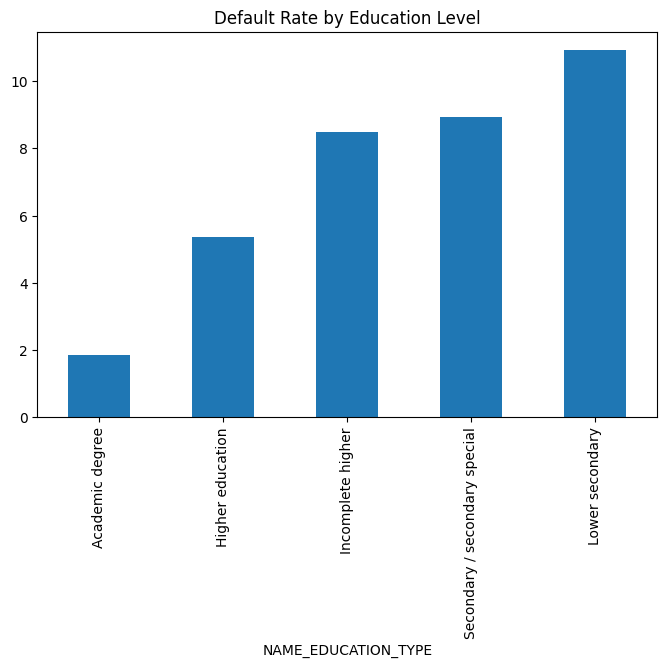

In [30]:
education_risk[1].sort_values().plot(
    kind='bar',
    figsize=(8,5),
    title='Default Rate by Education Level'
)

homeowners vs default risk

In [31]:
df['FLAG_OWN_REALTY'].value_counts()

FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64

In [32]:
pd.crosstab(df['FLAG_OWN_REALTY'], df['TARGET'], normalize='index') * 100

TARGET,0,1
FLAG_OWN_REALTY,,
N,91.675071,8.324929
Y,92.038423,7.961577


Property ownership exhibits a modest relationship with default risk. Applicants owning real estate showed a slightly lower default rate (7.96%) compared with non-homeowners (8.32%), suggesting that real estate ownership alone may not be a strong predictor of creditworthiness.

In [33]:
df['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [34]:
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365

df['AGE_YEARS'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

<Axes: >

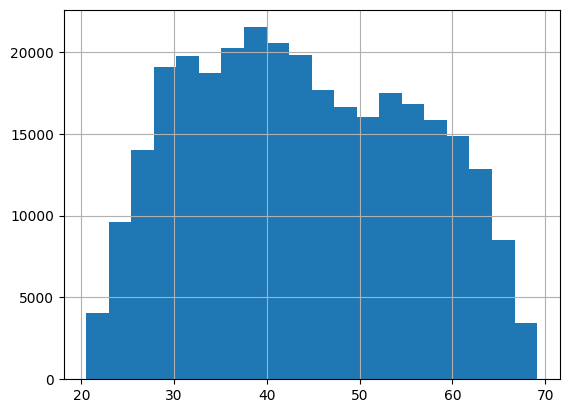

In [35]:
df['AGE_YEARS'].hist(bins=20)

In [36]:
df['AGE_GROUP'] = pd.cut(df['AGE_YEARS'],bins = [20,30,40,50,60,70], labels=['20-30','30-40','40-50','50-60','60-70'])

In [37]:
df['AGE_GROUP'].value_counts()

AGE_GROUP
30-40    82308
40-50    76541
50-60    68062
20-30    45021
60-70    35579
Name: count, dtype: int64

In [38]:
pd.crosstab(df['AGE_GROUP'],df['TARGET'],normalize = 'index')*100

TARGET,0,1
AGE_GROUP,,
20-30,88.543124,11.456876
30-40,90.416484,9.583516
40-50,92.349198,7.650802
50-60,93.870295,6.129705
60-70,95.078558,4.921442


people of age group 20-30 are more prone to default followed by 30-40 , then 40-50 while 60-70 age group people are at least risk of default
Younger applicants exhibit higher default risk, while default rates decrease steadily with age. Applicants aged 20–30 have more than double the default rate of applicants aged 60–70.

In [39]:
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [40]:
df['YEARS_EMPLOYED'] = abs(df['DAYS_EMPLOYED'] / 365)

In [41]:
df['YEARS_EMPLOYED'].value_counts()

YEARS_EMPLOYED
1000.665753    55374
0.547945         156
0.613699         152
0.545205         151
0.630137         151
               ...  
33.742466          1
30.410959          1
35.536986          1
30.367123          1
23.819178          1
Name: count, Length: 12574, dtype: int64

max days employed was 365243 or 1000years employed which is clearly a special code.
it cannot be a real employment duration
Not a normal outlier  its a placeholder as pensioners or unemployed people cannot have days_employed

In [42]:
df[df['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

In [43]:
df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

In [44]:
df['YEARS_EMPLOYED_CLEAN'] = abs(df['DAYS_EMPLOYED_CLEAN']/365)

In [45]:
df['YEARS_EMPLOYED_CLEAN'].describe()

count    252137.000000
mean          6.531971
std           6.406466
min           0.000000
25%           2.101370
50%           4.515068
75%           8.698630
max          49.073973
Name: YEARS_EMPLOYED_CLEAN, dtype: float64

In [46]:
df['AGE_YEARS']=abs(df['DAYS_BIRTH']/365)

In [47]:
df['AGE_YEARS'].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE_YEARS, dtype: float64

In [48]:
df.isnull().sum().sort_values(ascending=False).head(20)

EXT_SOURCE_1                    173378
FLOORSMAX_MEDI                  153020
FLOORSMAX_AVG                   153020
FLOORSMAX_MODE                  153020
YEARS_BEGINEXPLUATATION_MODE    150007
YEARS_BEGINEXPLUATATION_MEDI    150007
YEARS_BEGINEXPLUATATION_AVG     150007
TOTALAREA_MODE                  148431
EMERGENCYSTATE_MODE             145755
OCCUPATION_TYPE                  96391
EXT_SOURCE_3                     60965
DAYS_EMPLOYED_CLEAN              55374
YEARS_EMPLOYED_CLEAN             55374
AMT_REQ_CREDIT_BUREAU_YEAR       41519
AMT_REQ_CREDIT_BUREAU_HOUR       41519
AMT_REQ_CREDIT_BUREAU_WEEK       41519
AMT_REQ_CREDIT_BUREAU_DAY        41519
AMT_REQ_CREDIT_BUREAU_MON        41519
AMT_REQ_CREDIT_BUREAU_QRT        41519
NAME_TYPE_SUITE                   1292
dtype: int64

In [49]:
df['AMT_INCOME_TOTAL'].describe()

count    3.075110e+05
mean     1.687979e+05
std      2.371231e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64

In [50]:
df['AMT_INCOME_TOTAL'].quantile([0.25,0.5,0.75,0.9,0.95,0.99])
 #quantile splits data into equal sized portions like if 0.99 ie 99% customers lie below income 4,72,500
 # used for outlier detection
 #income is highly skewed so used qcut to create equal sized groups so it makes deafult rate comparison easier across groups

0.25    112500.0
0.50    147150.0
0.75    202500.0
0.90    270000.0
0.95    337500.0
0.99    472500.0
Name: AMT_INCOME_TOTAL, dtype: float64

In [51]:
df['INCOME_GROUP'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=5, duplicates = 'drop')

In [52]:
pd.crosstab(df['INCOME_GROUP'],df['TARGET'],normalize = 'index')*100

TARGET,0,1
INCOME_GROUP,,
"(25649.999, 99000.0]",91.793752,8.206248
"(99000.0, 135000.0]",91.411680,8.588320
"(135000.0, 162000.0]",91.315262,8.684738
"(162000.0, 225000.0]",91.943109,8.056891
"(225000.0, 117000000.0]",93.480199,6.519801


Income exhibits a weaker relationship with default risk than age or education. Most income groups show similar default rates (~8–9%), although the highest-income segment demonstrates a noticeably lower default rate (~6.5%).

## Key EDA Findings

1. Dataset is highly imbalanced (8.07% defaults).

2. Age is strongly associated with default risk.
   Younger applicants default more frequently.

3. Higher education levels are associated with lower default rates.

4. Income type influences risk, with pensioners and state servants exhibiting lower default rates.

5. The highest income segment demonstrates lower risk, although income is less predictive than age or education.

6. A significant anomaly was identified in DAYS_EMPLOYED, where 55,374 records contained a placeholder value of 365243 days (~1000 years).

In [53]:
df['EMPLOYMENT_GROUP'] = pd.cut(df['YEARS_EMPLOYED_CLEAN'],bins=[0,5,10,20,30,50])

In [54]:
pd.crosstab(df['EMPLOYMENT_GROUP'],df['TARGET'],normalize = 'index')*100

TARGET,0,1
EMPLOYMENT_GROUP,,
"(0, 5]",89.429165,10.570835
"(5, 10]",92.628561,7.371439
"(10, 20]",94.486692,5.513308
"(20, 30]",95.508324,4.491676
"(30, 50]",96.772047,3.227953


FEATURE ENGINEERING - CREATING RATIOS

In [55]:
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT']/df['AMT_INCOME_TOTAL']
df['CREDIT_INCOME_RATIO'].describe()

count    307511.000000
mean          3.957570
std           2.689728
min           0.004808
25%           2.018667
50%           3.265067
75%           5.159880
max          84.736842
Name: CREDIT_INCOME_RATIO, dtype: float64

if we notice 25p ~2, 50p ~3 , 75p ~5 and max 84 so this is right skewed distribution

In [56]:
df['CREDIT_INCOME_GROUP'] = pd.qcut(df['CREDIT_INCOME_RATIO'],q=5, duplicates = 'drop')

In [57]:
pd.crosstab(df['CREDIT_INCOME_GROUP'],df['TARGET'],normalize = 'index')*100

TARGET,0,1
CREDIT_INCOME_GROUP,,
"(0.00381, 1.818]",92.664814,7.335186
"(1.818, 2.764]",91.432799,8.567201
"(2.764, 3.906]",91.074741,8.925259
"(3.906, 5.769]",91.716121,8.283879
"(5.769, 84.737]",92.746224,7.253776


In [58]:
df['ANNUTIYY_INCOME_RATIO'] = df['AMT_ANNUITY']/df['AMT_INCOME_TOTAL']

In [59]:
df['ANNUTIYY_INCOME_RATIO'].describe()

count    307499.000000
mean          0.180930
std           0.094574
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965
Name: ANNUTIYY_INCOME_RATIO, dtype: float64

In [60]:
df['ANNUITY_INCOME_GROUP'] = pd.qcut(df['ANNUTIYY_INCOME_RATIO'], q=5, duplicates = 'drop')

In [61]:
pd.crosstab(df['ANNUITY_INCOME_GROUP'],df['TARGET'],normalize = 'index')*100

TARGET,0,1
ANNUITY_INCOME_GROUP,,
"(-0.000776, 0.104]",92.803252,7.196748
"(0.104, 0.144]",92.168371,7.831629
"(0.144, 0.186]",91.874004,8.125996
"(0.186, 0.247]",91.303924,8.696076
"(0.247, 1.876]",91.484482,8.515518


In [62]:
df['IS_PENSIONER'] = (df['NAME_INCOME_TYPE']=='Pensioner').astype(int)

In [63]:
df.drop('EMPLOYMENT_GROUP',axis=1,inplace=True)

In [64]:
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Missing')

In [65]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'YEARS_BEGINEXPLUATAT

In [66]:
df['EXT_SOURCE_1'] = df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_1'].median()) 
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].median())

In [67]:
df['EXT_SOURCE_3'].value_counts()

EXT_SOURCE_3
0.535276    61751
0.746300     1460
0.713631     1315
0.694093     1276
0.670652     1191
            ...  
0.018924        1
0.029079        1
0.018137        1
0.020026        1
0.043227        1
Name: count, Length: 814, dtype: int64

In [68]:
[col for col in df.columns if 'ANNU' in col]

['AMT_ANNUITY', 'ANNUTIYY_INCOME_RATIO', 'ANNUITY_INCOME_GROUP']

In [69]:
(df.isnull().sum()/len(df)*100)\
.sort_values(ascending=False)\
.head(20)

FLOORSMAX_AVG                   49.760822
FLOORSMAX_MODE                  49.760822
FLOORSMAX_MEDI                  49.760822
YEARS_BEGINEXPLUATATION_AVG     48.781019
YEARS_BEGINEXPLUATATION_MEDI    48.781019
YEARS_BEGINEXPLUATATION_MODE    48.781019
TOTALAREA_MODE                  48.268517
EMERGENCYSTATE_MODE             47.398304
YEARS_EMPLOYED_CLEAN            18.007161
DAYS_EMPLOYED_CLEAN             18.007161
AMT_REQ_CREDIT_BUREAU_YEAR      13.501631
AMT_REQ_CREDIT_BUREAU_QRT       13.501631
AMT_REQ_CREDIT_BUREAU_MON       13.501631
AMT_REQ_CREDIT_BUREAU_WEEK      13.501631
AMT_REQ_CREDIT_BUREAU_DAY       13.501631
AMT_REQ_CREDIT_BUREAU_HOUR      13.501631
NAME_TYPE_SUITE                  0.420148
OBS_60_CNT_SOCIAL_CIRCLE         0.332021
DEF_60_CNT_SOCIAL_CIRCLE         0.332021
OBS_30_CNT_SOCIAL_CIRCLE         0.332021
dtype: float64

In [70]:
df.drop(columns=['FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI',
'YEARS_BEGINEXPLUATATION_MEDI','YEARS_BEGINEXPLUATATION_MODE','YEARS_BEGINEXPLUATATION_AVG',
'TOTALAREA_MODE','EMERGENCYSTATE_MODE'],inplace=True)

In [71]:
df['YEARS_EMPLOYED_CLEAN'] = df['YEARS_EMPLOYED_CLEAN'].fillna(0)
df['DAYS_EMPLOYED_CLEAN'] = df['DAYS_EMPLOYED_CLEAN'].fillna(0)

In [72]:
bureau_cols = [
    'AMT_REQ_CREDIT_BUREAU_YEAR',
    'AMT_REQ_CREDIT_BUREAU_QRT',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_WEEK',
    'AMT_REQ_CREDIT_BUREAU_DAY',
    'AMT_REQ_CREDIT_BUREAU_HOUR'
]

df[bureau_cols] = df[bureau_cols].fillna(0)

In [73]:
df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna(df['NAME_TYPE_SUITE'].mode()[0])

In [74]:
social_cols = [
    'OBS_60_CNT_SOCIAL_CIRCLE',
    'DEF_60_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'DEF_30_CNT_SOCIAL_CIRCLE'
]

for col in social_cols:
    df[col] = df[col].fillna(df[col].median())

In [75]:
(df.isnull().sum()/len(df)*100)\
.sort_values(ascending=False)\
.head(20)

EXT_SOURCE_2              0.214626
AMT_GOODS_PRICE           0.090403
AMT_ANNUITY               0.003902
ANNUITY_INCOME_GROUP      0.003902
ANNUTIYY_INCOME_RATIO     0.003902
CNT_FAM_MEMBERS           0.000650
DAYS_LAST_PHONE_CHANGE    0.000325
FLAG_OWN_REALTY           0.000000
CODE_GENDER               0.000000
FLAG_OWN_CAR              0.000000
AMT_INCOME_TOTAL          0.000000
NAME_TYPE_SUITE           0.000000
NAME_INCOME_TYPE          0.000000
NAME_EDUCATION_TYPE       0.000000
NAME_FAMILY_STATUS        0.000000
NAME_HOUSING_TYPE         0.000000
CNT_CHILDREN              0.000000
AMT_CREDIT                0.000000
NAME_CONTRACT_TYPE        0.000000
TARGET                    0.000000
dtype: float64

In [76]:
numeric_fill_cols = [
    'EXT_SOURCE_2',
    'AMT_GOODS_PRICE',
    'AMT_ANNUITY',
    'CNT_FAM_MEMBERS',
    'DAYS_LAST_PHONE_CHANGE',
    'ANNUTIYY_INCOME_RATIO',
]

for col in numeric_fill_cols:
    df[col] = df[col].fillna(df[col].median())

In [77]:
df.drop('ANNUITY_INCOME_GROUP',axis=1,inplace=True)

In [78]:
df.isnull().sum().sort_values(ascending=False).head(20)

SK_ID_CURR                    0
TARGET                        0
NAME_CONTRACT_TYPE            0
CODE_GENDER                   0
FLAG_OWN_CAR                  0
FLAG_OWN_REALTY               0
CNT_CHILDREN                  0
AMT_INCOME_TOTAL              0
AMT_CREDIT                    0
AMT_ANNUITY                   0
AMT_GOODS_PRICE               0
NAME_TYPE_SUITE               0
NAME_INCOME_TYPE              0
NAME_EDUCATION_TYPE           0
NAME_FAMILY_STATUS            0
NAME_HOUSING_TYPE             0
REGION_POPULATION_RELATIVE    0
DAYS_BIRTH                    0
DAYS_EMPLOYED                 0
DAYS_REGISTRATION             0
dtype: int64

In [79]:
df.shape

(307511, 84)

In [80]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

C:\Users\diyak\AppData\Local\Temp\ipykernel_11428\2528409226.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE'],
      dtype='str')

DATA PREPROCESSING

In [81]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

In [82]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [83]:
X = X.drop(
    columns=[
        'AGE_GROUP',
        'INCOME_GROUP',
        'CREDIT_INCOME_GROUP'
    ],
    errors='ignore'
)

In [84]:
X.shape

(307511, 181)

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(246008, 181)
(61503, 181)


In [86]:
y.value_counts(normalize=True)*100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [87]:
X.select_dtypes(include=['category']).columns.tolist()

[]

In [88]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MODEL TRAINING

In [89]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression(max_iter=1000, random_state=42)

model.fit(X_train_scaled,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [90]:
y_predict = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

In [91]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  

print(classification_report(y_test, y_predict))
print(confusion_matrix(y_test, y_predict))
print('ROC-AUC',roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.55      0.01      0.02      4965

    accuracy                           0.92     61503
   macro avg       0.73      0.51      0.49     61503
weighted avg       0.89      0.92      0.88     61503

[[56488    50]
 [ 4904    61]]
ROC-AUC 0.7483898556655227


In [92]:
model1 = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')

model1.fit(X_train_scaled,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [93]:
y_pred1 = model1.predict(X_test_scaled)
y_prob = model1.predict_proba(X_test_scaled)[:,1]
print(classification_report(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))        
print('ROC-AUC',roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

[[39039 17499]
 [ 1614  3351]]
ROC-AUC 0.7485447194709067


In [107]:
print(y_prob)

[0.3681313  0.32137978 0.78602828 ... 0.34598847 0.66747111 0.67602086]


In [96]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42,n_jobs=-1,class_weight='balanced')

rf_model.fit(X_train_scaled,y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [97]:
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:,1]

print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print('ROC-AUC',roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.44      0.04      0.08      4965

    accuracy                           0.92     61503
   macro avg       0.68      0.52      0.52     61503
weighted avg       0.88      0.92      0.89     61503

[[56259   279]
 [ 4743   222]]
ROC-AUC 0.738649224396735


In [101]:
from xgboost import XGBClassifier

spw = len(y_train[y_train==0]) / len(y_train[y_train==1])
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:,1]
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print('ROC-AUC',roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.96      0.71      0.81     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503

[[40009 16529]
 [ 1635  3330]]
ROC-AUC 0.7565826183546597


In [113]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(20)

,Feature,Importance
29,EXT_SOURCE_3,0.073517
28,EXT_SOURCE_2,0.067991
86,NAME_EDUCATION_TYPE_Higher education,0.043558
62,YEARS_EMPLOYED,0.029223
69,CODE_GENDER_M,0.026185
71,FLAG_OWN_CAR_Y,0.020506
27,EXT_SOURCE_1,0.020389
89,NAME_EDUCATION_TYPE_Secondary / secondary special,0.019628
61,AGE_YEARS,0.018305
36,FLAG_DOCUMENT_3,0.018290


In [104]:
results = pd.DataFrame({
    'Model':['Logistic','Logistic Balanced','Random Forest','XGBoost'],
    'ROC_AUC':[0.748,0.748,0.739,0.757],
    'Recall':[0.01,0.67,0.04,0.67]
})

results

,Model,ROC_AUC,Recall
0,Logistic,0.748,0.01
1,Logistic Balanced,0.748,0.67
2,Random Forest,0.739,0.04
3,XGBoost,0.757,0.67


Although XGBoost achieved the highest ROC-AUC (0.757), its performance improvement over the balanced Logistic Regression model (0.748) was marginal. Given the comparable recall and substantially greater interpretability and computational efficiency of Logistic Regression, the balanced Logistic Regression model was selected as the preferred model for deployment.

 EXPLAINABILITY

In [109]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model1.coef_[0]
})

coef_df['Abs_Coeff'] = abs(coef_df['Coefficient'])

coef_df.sort_values(
    'Abs_Coeff',
    ascending=False
).head(20)

,Feature,Coefficient,Abs_Coeff
5,AMT_GOODS_PRICE,-0.980164,0.980164
3,AMT_CREDIT,0.909264,0.909264
29,EXT_SOURCE_3,-0.483272,0.483272
28,EXT_SOURCE_2,-0.388903,0.388903
27,EXT_SOURCE_1,-0.180221,0.180221
69,CODE_GENDER_M,0.158830,0.158830
19,REGION_RATING_CLIENT_W_CITY,0.153226,0.153226
2,AMT_INCOME_TOTAL,0.147783,0.147783
89,NAME_EDUCATION_TYPE_Secondary / secondary special,0.142111,0.142111
36,FLAG_DOCUMENT_3,0.137345,0.137345


Key Risk Drivers
Higher credit amounts increased default risk.
Higher annuity-to-income ratios increased default risk.
Regional risk ratings were positively associated with default.
Shorter employment histories were associated with higher risk.

Protective Factors
External credit scores (EXT_SOURCE_1, 2, and 3) were the strongest indicators of lower default risk.
Longer employment tenure reduced default risk.
Asset ownership indicators such as car ownership were associated with lower risk.

In [114]:
X_scaled = scaler.transform(X)

In [115]:
default_prob = model1.predict_proba(X_scaled)[:,1]

In [116]:
len(default_prob)

307511

In [117]:
df_seg = df.copy()

df_seg['Default_Probability'] = default_prob

In [118]:
df_seg[['TARGET','Default_Probability']].head()

,TARGET,Default_Probability
0,1,0.950963
1,0,0.275985
2,0,0.262317
3,0,0.419451
4,0,0.457607


In [119]:
df_seg['Default_Probability'].describe()

count    3.075110e+05
mean     4.221847e-01
std      1.998708e-01
min      1.580520e-10
25%      2.625691e-01
50%      3.991024e-01
75%      5.659598e-01
max      1.000000e+00
Name: Default_Probability, dtype: float64

RISK SEGMENTATION

In [120]:
df_seg['Risk_Segment'] = pd.qcut(
    df_seg['Default_Probability'],
    q=4,
    labels=[
        'Low Risk',
        'Medium Risk',
        'High Risk',
        'Very High Risk'
    ]
)

In [121]:
df_seg['Risk_Segment'].value_counts()

Risk_Segment
Low Risk          76878
Medium Risk       76878
Very High Risk    76878
High Risk         76877
Name: count, dtype: int64

LENDING DECISION ENGINE

In [122]:
def lending_decision(segment):

    if segment == 'Low Risk':
        return 'Approve'

    elif segment == 'Medium Risk':
        return 'Approve with Conditions'

    elif segment == 'High Risk':
        return 'Manual Review'

    else:
        return 'Reject'

In [123]:
df_seg['Decision'] = (
    df_seg['Risk_Segment']
    .apply(lending_decision)
)

In [144]:
df_seg['Decision'].value_counts()

Decision
Approve                    76878
Approve with Conditions    76878
Reject                     76878
Manual Review              76877
Name: count, dtype: int64

In [148]:
df_seg['Risk_Segment'].value_counts()

Risk_Segment
Low Risk          76878
Medium Risk       76878
Very High Risk    76878
High Risk         76877
Name: count, dtype: int64

BANKS BUDGET :10 CRORE

In [ ]:
df_seg['Expected_Loss'] = (df_seg['Default_Probability']* df_seg['AMT_CREDIT'])

In [126]:
df_seg['Expected_Safe_Amount'] = (
    (1 - df_seg['Default_Probability'])
    * df_seg['AMT_CREDIT']
)

In [127]:
df_opt = df_seg.sort_values(
    'Expected_Safe_Amount',
    ascending=False
)

In [142]:
df_opt.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CI

In [130]:
budget = 10_00_00_000

In [128]:
df_opt['Cumulative_Loan'] = (
    df_opt['AMT_CREDIT']
    .cumsum()
)

In [131]:
df_opt['Approved_Under_Budget'] = (
    df_opt['Cumulative_Loan'] <= budget
)

In [132]:
df_opt['Approved_Under_Budget'].value_counts()

Approved_Under_Budget
False    307483
True         28
Name: count, dtype: int64

In [133]:
df_opt[['AMT_CREDIT',
        'Default_Probability',
        'Expected_Safe_Amount']].head(20)

,AMT_CREDIT,Default_Probability,Expected_Safe_Amount
133766,4050000.0,0.032990,3.916390e+06
288455,4050000.0,0.037819,3.896834e+06
14852,4050000.0,0.081413,3.720279e+06
119681,4050000.0,0.082891,3.714293e+06
14643,3956274.0,0.062653,3.708403e+06
287732,4050000.0,0.097201,3.656335e+06
120757,4050000.0,0.107546,3.614437e+06
17948,4050000.0,0.135476,3.501321e+06
119380,3860019.0,0.131033,3.354227e+06
53936,3600000.0,0.086523,3.288518e+06


In [134]:
df_opt['AMT_CREDIT'].describe()

count    3.075110e+05
mean     5.990260e+05
std      4.024908e+05
min      4.500000e+04
25%      2.700000e+05
50%      5.135310e+05
75%      8.086500e+05
max      4.050000e+06
Name: AMT_CREDIT, dtype: float64

Interest Rate = 12%

Profitability Analysis

In [151]:
interest_rate = 0.12

df_opt['Expected_Profit'] = (
    df_opt['AMT_CREDIT'] * interest_rate * (1 - df_opt['Default_Probability'])
    -
    df_opt['AMT_CREDIT'] * df_opt['Default_Probability']
)

In [152]:
df_opt['Expected_Profit'].describe()

count    3.075110e+05
mean    -2.003968e+05
std      1.874127e+05
min     -1.821732e+06
25%     -2.826923e+05
50%     -1.458695e+05
75%     -6.531685e+04
max      3.363569e+05
Name: Expected_Profit, dtype: float64

In [153]:
df_opt[['AMT_CREDIT',
        'Default_Probability',
        'Expected_Profit']].head(20)

,AMT_CREDIT,Default_Probability,Expected_Profit
133766,4050000.0,0.032990,336356.948434
288455,4050000.0,0.037819,314454.097395
14852,4050000.0,0.081413,116712.322980
119681,4050000.0,0.082891,110007.610935
14643,3956274.0,0.062653,197137.086215
287732,4050000.0,0.097201,45095.158355
120757,4050000.0,0.107546,-1830.493124
17948,4050000.0,0.135476,-128520.206682
119380,3860019.0,0.131033,-103284.464073
53936,3600000.0,0.086523,83140.404062


In [154]:
df_profitable = df_opt[df_opt['Expected_Profit'] > 0]

df_profitable.shape

(7961, 92)

In [155]:
df_profitable['Expected_Profit'].describe()

count      7961.000000
mean      25001.446831
std       32202.824071
min           1.133673
25%        5013.425990
50%       13076.903122
75%       32044.746568
max      336356.948434
Name: Expected_Profit, dtype: float64

In [156]:
df_profitable['Expected_Profit'].sum()

np.float64(199036518.21859574)

GREEDY HEURISTIC

In [157]:
df_profitable = df_profitable.sort_values(
    'Expected_Profit',
    ascending=False
)

In [158]:
budget = 10_00_00_000

df_profitable['Cumulative_Loan'] = (
    df_profitable['AMT_CREDIT']
    .cumsum()
)

df_profitable['Approved'] = (
    df_profitable['Cumulative_Loan']
    <= budget
)

In [159]:
approved = df_profitable[
    df_profitable['Approved']
]

approved.shape

(38, 93)

In [160]:
approved['Expected_Profit'].sum()

np.float64(8287876.30639548)

PORTFOLIO OPTIMIZATION

APPLYING BINARY INT PROGRAMMING / 0-1 KNAPSACK PROB

DECISION VAR- 
xᵢ = 1 if loan approved
xᵢ = 0 otherwise

OBJECTIVE FUNC-
Maximize
Σ(Expected_Profitᵢ × xᵢ)

CONSTRAINT-
Σ(LoanAmountᵢ × xᵢ)≤ Budget   (assuming budget = 10 crore)
xᵢ ∈ {0,1}


In [203]:
df_profitable.shape

(7961, 93)

In [162]:
from pulp import*

In [215]:
df_knapsack = (
    df_profitable
    .nlargest(7961, 'Expected_Profit')
    .copy()
)

In [226]:
df_knapsack.shape

(7961, 93)

In [216]:
budget = 10_00_00_000

lp_model = LpProblem(
    "Loan_Portfolio_Optimization",
    LpMaximize
)

In [217]:
x = LpVariable.dicts(
    "Approve",
    df_knapsack.index,
    cat='Binary'
)

In [228]:
len(x)

7961

In [218]:
lp_model += lpSum(
    df_knapsack.loc[i,'Expected_Profit'] * x[i]
    for i in df_knapsack.index
)

In [219]:
lp_model += lpSum(
    df_knapsack.loc[i,'AMT_CREDIT'] * x[i]
    for i in df_knapsack.index
) <= budget

In [220]:
%%time
lp_model.solve()

CPU times: total: 109 ms
Wall time: 765 ms


1

In [221]:
approved_idx = [
    i
    for i in df_knapsack.index
    if x[i].value()==1
]

In [222]:
optimal_portfolio = df_knapsack.loc[
    approved_idx
]

In [223]:
optimal_portfolio[
    'Expected_Profit'
].sum()

np.float64(10440029.316141505)

In [224]:
optimal_portfolio[
    'AMT_CREDIT'
].sum()

np.float64(99997393.5)

In [225]:
print(optimal_portfolio.shape)
print(optimal_portfolio['Expected_Profit'].sum())
print(optimal_portfolio['AMT_CREDIT'].sum())

(111, 93)
10440029.316141505
99997393.5


| Metric                | Value        |
| --------------------- | ------------ |
| Total Applicants      | 307,511      |
| Profitable Applicants | 7,961        |
| Budget                | ₹10 Crore    |
| Selected Applicants   | 111          |
| Portfolio Profit      | ₹1.044 Crore |
